In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/chetanvedi
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_5153
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_5886
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_1900
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_5519
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_4947
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_4819
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_5073
/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized/cattle_5

In [2]:
import os

dataset_path = "/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized"

folders = os.listdir(dataset_path)

print("Total Classes:", len(folders))
print("First 10 Classes:")
print(folders[:10])

Total Classes: 268
First 10 Classes:
['cattle_5153', 'cattle_5886', 'cattle_1900', 'cattle_5519', 'cattle_4947', 'cattle_4819', 'cattle_5073', 'cattle_5403', 'cattle_6084', 'cattle_4984']


In [3]:
import os

dataset_path = "/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized"

total_images = 0

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        total_images += len(os.listdir(folder_path))

print("Total Images:", total_images)

Total Images: 4923


# Output-  So in this Beef Cattle Muzzule dataset total class 268 and total image4923

# Check Minimum or Maximum number of Images

In [4]:
import os

dataset_path = "/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized"

image_counts = {}

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        image_counts[folder] = count

min_id = min(image_counts, key=image_counts.get)
max_id = max(image_counts, key=image_counts.get)

print("Minimum Images:")
print(min_id, "->", image_counts[min_id])

print("\nMaximum Images:")
print(max_id, "->", image_counts[max_id])

Minimum Images:
cattle_3420 -> 4

Maximum Images:
cattle_4613 -> 70


# output- Minium cow image = 4 in cattle_3420
#          Maximum Cow image = 70 in cattle_4613

# Distribution Histogram

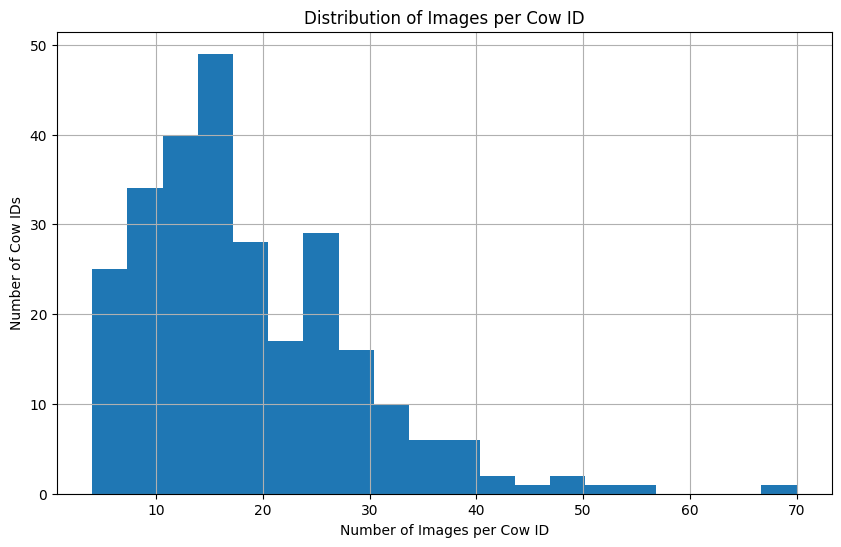

Plot Saved Successfully
Location: /kaggle/working/EDA_CowID_Image_Distribution/cowid_image_distribution_histogram.png


In [5]:
import os
import matplotlib.pyplot as plt

# Dataset Path
dataset_path = "/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized"

# Create Folder for this Task
save_dir = "/kaggle/working/EDA_CowID_Image_Distribution"
os.makedirs(save_dir, exist_ok=True)

# Count Images per Cow ID
image_counts = []

for cow_id in os.listdir(dataset_path):
    cow_path = os.path.join(dataset_path, cow_id)

    if os.path.isdir(cow_path):
        num_images = len(os.listdir(cow_path))
        image_counts.append(num_images)

# Histogram Plot
plt.figure(figsize=(10, 6))
plt.hist(image_counts, bins=20)

plt.title("Distribution of Images per Cow ID")
plt.xlabel("Number of Images per Cow ID")
plt.ylabel("Number of Cow IDs")

plt.grid(True)

# Save Plot
plot_path = os.path.join(save_dir, "cowid_image_distribution_histogram.png")
plt.savefig(plot_path, bbox_inches="tight")

plt.show()

print("Plot Saved Successfully")
print("Location:", plot_path)

# Output - The distribution of images per cow ID is right-skewed, with most cow IDs containing 10–25 images, while a few IDs have significantly larger numbers of images, indicating moderate class imbalance within the dataset.

# Split Data Acording to Threshold = 10 

In [6]:
import os
import shutil

# Dataset Path
dataset_path = "/kaggle/input/datasets/chetanvedi/beef-cattle-db-work/BeefCattle_Muzzle_Individualized"

# Threshold
threshold = 10

# Create Output Folders
base_dir = "/kaggle/working/Known_Unknown_Cattle_Split"

known_dir = os.path.join(base_dir, "Known_Cattle")
unknown_dir = os.path.join(base_dir, "Unknown_Cattle")

os.makedirs(known_dir, exist_ok=True)
os.makedirs(unknown_dir, exist_ok=True)

# Split Dataset
for cow_id in os.listdir(dataset_path):

    cow_path = os.path.join(dataset_path, cow_id)

    if os.path.isdir(cow_path):

        image_count = len(os.listdir(cow_path))

        if image_count >= threshold:
            shutil.copytree(
                cow_path,
                os.path.join(known_dir, cow_id),
                dirs_exist_ok=True
            )
        else:
            shutil.copytree(
                cow_path,
                os.path.join(unknown_dir, cow_id),
                dirs_exist_ok=True
            )

print("Split Completed Successfully")
print("Known Cattle Folder :", known_dir)
print("Unknown Cattle Folder :", unknown_dir)

Split Completed Successfully
Known Cattle Folder : /kaggle/working/Known_Unknown_Cattle_Split/Known_Cattle
Unknown Cattle Folder : /kaggle/working/Known_Unknown_Cattle_Split/Unknown_Cattle


In [7]:
print("Known Cattle IDs :", len(os.listdir(known_dir)))
print("Unknown Cattle IDs :", len(os.listdir(unknown_dir)))

Known Cattle IDs : 227
Unknown Cattle IDs : 41


In [8]:
import os

known_dir = "/kaggle/working/Known_Unknown_Cattle_Split/Known_Cattle"
unknown_dir = "/kaggle/working/Known_Unknown_Cattle_Split/Unknown_Cattle"

known_images = 0
unknown_images = 0

for cow_id in os.listdir(known_dir):
    cow_path = os.path.join(known_dir, cow_id)

    if os.path.isdir(cow_path):
        known_images += len(os.listdir(cow_path))

for cow_id in os.listdir(unknown_dir):
    cow_path = os.path.join(unknown_dir, cow_id)

    if os.path.isdir(cow_path):
        unknown_images += len(os.listdir(cow_path))

print("Known Cattle")
print("Total IDs:", len(os.listdir(known_dir)))
print("Total Images:", known_images)

print("\nUnknown Cattle")
print("Total IDs:", len(os.listdir(unknown_dir)))
print("Total Images:", unknown_images)


print("Total Images After Split:", known_images + unknown_images)

Known Cattle
Total IDs: 227
Total Images: 4656

Unknown Cattle
Total IDs: 41
Total Images: 267
Total Images After Split: 4923


# Output - Known Cattle
#         Total IDs: 227
#      Total Images: 4656

#         Unknown Cattle
#        Total IDs: 41
#      Total Images: 267
#     Total Images After Split: 4923"""

# Split Known Dataset into Train, Test, Validation

In [9]:
import os
import shutil
import random

# Reproducibility
random.seed(42)

# Known Cattle Path
known_dir = "/kaggle/working/Known_Unknown_Cattle_Split/Known_Cattle"

# Output Folder
split_dir = "/kaggle/working/Known_Split"

train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")
test_dir = os.path.join(split_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Split Each Cow ID
for cow_id in os.listdir(known_dir):

    cow_path = os.path.join(known_dir, cow_id)

    if not os.path.isdir(cow_path):
        continue

    images = os.listdir(cow_path)
    random.shuffle(images)

    total = len(images)

    train_count = int(total * 0.70)
    val_count = int(total * 0.15)

    train_imgs = images[:train_count]
    val_imgs = images[train_count:train_count + val_count]
    test_imgs = images[train_count + val_count:]

    # Create Cow ID folders
    os.makedirs(os.path.join(train_dir, cow_id), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cow_id), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cow_id), exist_ok=True)

    # Copy Train Images
    for img in train_imgs:
        shutil.copy(
            os.path.join(cow_path, img),
            os.path.join(train_dir, cow_id, img)
        )

    # Copy Validation Images
    for img in val_imgs:
        shutil.copy(
            os.path.join(cow_path, img),
            os.path.join(val_dir, cow_id, img)
        )

    # Copy Test Images
    for img in test_imgs:
        shutil.copy(
            os.path.join(cow_path, img),
            os.path.join(test_dir, cow_id, img)
        )

print("Known Cattle Split Completed")

Known Cattle Split Completed


In [10]:
import os

train_dir = "/kaggle/working/Known_Split/train"
val_dir = "/kaggle/working/Known_Split/val"
test_dir = "/kaggle/working/Known_Split/test"

def count_images(folder):
    total = 0

    for cow_id in os.listdir(folder):
        cow_path = os.path.join(folder, cow_id)

        if os.path.isdir(cow_path):
            total += len(os.listdir(cow_path))

    return total

train_images = count_images(train_dir)
val_images = count_images(val_dir)
test_images = count_images(test_dir)

total_images = train_images + val_images + test_images

print(f"Train Images : {train_images} ({train_images/total_images*100:.2f}%)")
print(f"Val Images   : {val_images} ({val_images/total_images*100:.2f}%)")
print(f"Test Images  : {test_images} ({test_images/total_images*100:.2f}%)")

print("-" * 40)
print(f"Total Images : {total_images}")

Train Images : 3164 (67.96%)
Val Images   : 582 (12.50%)
Test Images  : 910 (19.54%)
----------------------------------------
Total Images : 4656


# output Train Images : 3164 (67.96%)
Val Images   : 582 (12.50%)
Test Images  : 910 (19.54%)
Total Images : 4656
-

In [11]:
import os

train_dir = "/kaggle/working/Known_Split/train"
val_dir = "/kaggle/working/Known_Split/val"
test_dir = "/kaggle/working/Known_Split/test"

print("Train IDs :", len(os.listdir(train_dir)))
print("Val IDs   :", len(os.listdir(val_dir)))
print("Test IDs  :", len(os.listdir(test_dir)))

Train IDs : 227
Val IDs   : 227
Test IDs  : 227


# 1) Create a custom pytorch Dataset Class . After reading each images, convert it from RGB to YCrCb color spacing using OpenCV.
# 2) Apply Contrast Limited Adaptive Histogram Equalization(CLAHE) only to the Y(luminance) channel with the following parameters: Clip Limit: 3.0 , Tile Grid Size :(8, 8)
# 3) After enhancement merge the channels and convert the image back to the RGB color space before returning it form the dataset .
# 4) apply augmentation only on training dataset Random Horizontal Flip Random Rotation within +- 15 degree

# Import Libraries

In [12]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Create Image Records DataFrame 
collect image path or cattle_Id form train ,test, val folder

In [13]:
def create_dataframe(dataset_dir):

    records = []

    for cattle_id in os.listdir(dataset_dir):

        cattle_path = os.path.join(dataset_dir, cattle_id)

        if os.path.isdir(cattle_path):

            for image_name in os.listdir(cattle_path):

                image_path = os.path.join(cattle_path, image_name)

                records.append([
                    image_path,
                    cattle_id
                ])

    return pd.DataFrame(
        records,
        columns=["filepath", "cattle_id"]
    )

# Create Train / Val / Test DataFrames

In [14]:
train_dir = "/kaggle/working/Known_Split/train"
val_dir   = "/kaggle/working/Known_Split/val"
test_dir  = "/kaggle/working/Known_Split/test"

train_imgs = create_dataframe(train_dir)
val_imgs   = create_dataframe(val_dir)
test_imgs  = create_dataframe(test_dir)

print("Train Images :", len(train_imgs))
print("Val Images   :", len(val_imgs))
print("Test Images  :", len(test_imgs))

Train Images : 3164
Val Images   : 582
Test Images  : 910


# Define Augmentation

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create Custom Dataset Class

In [16]:
class CattleMuzzleDataset(Dataset):

    def __init__(self, df_records, transform=None):

        self.filepaths = df_records["filepath"].values
        self.labels = df_records["cattle_id"].values
        self.transform = transform

        # Label Encoding
        self.unique_labels = sorted(list(set(self.labels)))
        self.label_to_idx = {
            label: idx
            for idx, label in enumerate(self.unique_labels)
        }

    def __len__(self):

        return len(self.filepaths)

    def __getitem__(self, idx):

        filepath = self.filepaths[idx]
        label_name = self.labels[idx]

        # Convert cattle ID to integer label
        label = self.label_to_idx[label_name]

        # Read Image
        img_bgr = cv2.imread(filepath)

        # Safety Check
        if img_bgr is None:
            img_bgr = np.zeros((224, 224, 3), dtype=np.uint8)

        # BGR -> RGB
        img_rgb = cv2.cvtColor(
            img_bgr,
            cv2.COLOR_BGR2RGB
        )

        # RGB -> YCrCb
        img_ycrcb = cv2.cvtColor(
            img_rgb,
            cv2.COLOR_RGB2YCrCb
        )

        # Split Channels
        y, cr, cb = cv2.split(img_ycrcb)

        # CLAHE on Y Channel
        clahe = cv2.createCLAHE(
            clipLimit=3.0,
            tileGridSize=(8, 8)
        )

        y_enhanced = clahe.apply(y)

        # Merge Channels
        ycrcb_enhanced = cv2.merge(
            (y_enhanced, cr, cb)
        )

        # YCrCb -> RGB
        img_enhanced_rgb = cv2.cvtColor(
            ycrcb_enhanced,
            cv2.COLOR_YCrCb2RGB
        )

        # Convert to PIL Image
        img_pil = Image.fromarray(
            img_enhanced_rgb
        )

        # Apply Transform
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        return img_tensor, label

# Create Datset Object

In [17]:
train_dataset = CattleMuzzleDataset(
    train_imgs,
    transform=train_transform
)

val_dataset = CattleMuzzleDataset(
    val_imgs,
    transform=val_test_transform
)

test_dataset = CattleMuzzleDataset(
    test_imgs,
    transform=val_test_transform
)

In [18]:
print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))
print("Test Dataset :", len(test_dataset))

Train Dataset : 3164
Validation Dataset : 582
Test Dataset : 910


# Check One Sample

In [19]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label :", label)

Image Shape : torch.Size([3, 224, 224])
Label : 35


In [20]:
idx_to_label = {v: k for k, v in train_dataset.label_to_idx.items()}

print(idx_to_label[176])

cattle_5971


# CLAHE Verification Visualization

In [21]:
import os

save_dir = "/kaggle/working/Preprocessing_CLAHE_Augmentation"
os.makedirs(save_dir, exist_ok=True)

print("Folder Created:", save_dir)

Folder Created: /kaggle/working/Preprocessing_CLAHE_Augmentation


In [22]:
sample_record = train_imgs.iloc[0]

sample_path = sample_record["filepath"]

# Original Image
img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# RGB -> YCrCb
img_ycrcb = cv2.cvtColor(
    img_rgb,
    cv2.COLOR_RGB2YCrCb
)

# Split Channels
y, cr, cb = cv2.split(img_ycrcb)

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8, 8)
)

y_enhanced = clahe.apply(y)

# Merge Channels
ycrcb_enhanced = cv2.merge(
    (y_enhanced, cr, cb)
)

# YCrCb -> RGB
img_enhanced_rgb = cv2.cvtColor(
    ycrcb_enhanced,
    cv2.COLOR_YCrCb2RGB
)

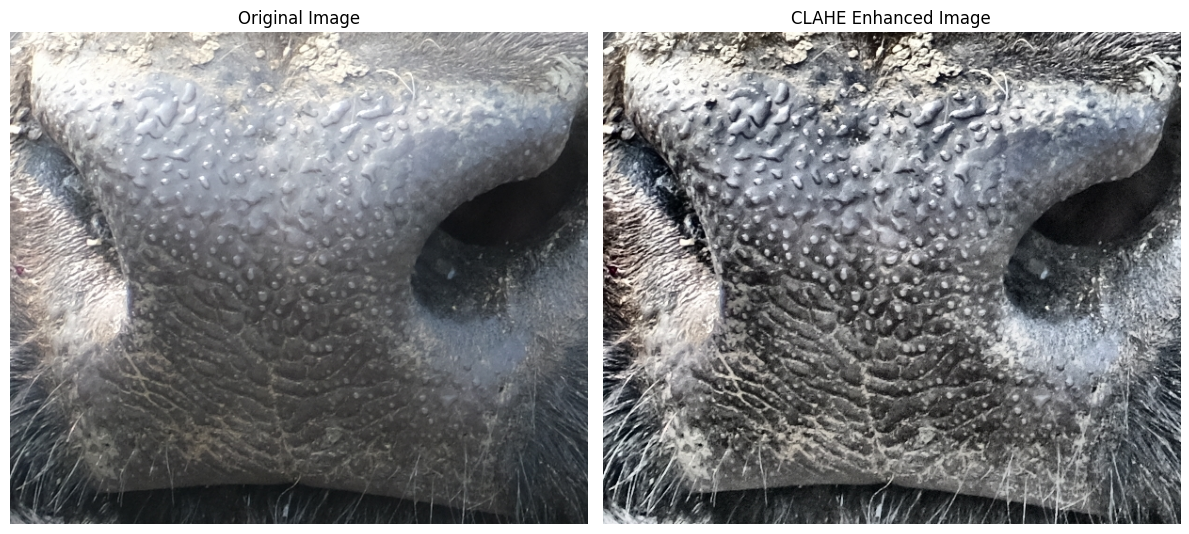

Saved At: /kaggle/working/Preprocessing_CLAHE_Augmentation/clahe_comparison.png


In [23]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_enhanced_rgb)
plt.title("CLAHE Enhanced Image")
plt.axis("off")

plt.tight_layout()

plot_path = os.path.join(
    save_dir,
    "clahe_comparison.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved At:", plot_path)

# MobileNetV2 + ArcFace

In [24]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

In [25]:
class ArcMarginProduct(nn.Module):

    def __init__(self, in_features, out_features,
                 s=30.0, m=0.50, easy_margin=False):

        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(
            torch.FloatTensor(out_features, in_features)
        )

        nn.init.xavier_uniform_(self.weight)

        self.easy_margin = easy_margin

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)

        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):

        cosine = F.linear(
            F.normalize(input),
            F.normalize(self.weight)
        )

        sine = torch.sqrt(
            1.0 - torch.pow(cosine, 2)
        ).clamp(0, 1)

        phi = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = torch.where(
                cosine > 0,
                phi,
                cosine
            )
        else:
            phi = torch.where(
                cosine > self.th,
                phi,
                cosine - self.mm
            )

        one_hot = torch.zeros(
            cosine.size(),
            device=input.device
        )

        one_hot.scatter_(
            1,
            label.view(-1, 1).long(),
            1
        )

        output = (
            one_hot * phi
        ) + (
            (1.0 - one_hot) * cosine
        )

        output *= self.s

        return output

In [26]:
class MobileNetV2ArcFace(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # MobileNetV2 Backbone
        self.backbone = timm.create_model(
            "mobilenetv2_100",
            pretrained=True,
            num_classes=0
        )

        # Feature Layer
        self.embedding = nn.Linear(
            1280,
            512
        )

        # Batch Normalization
        self.bn = nn.BatchNorm1d(
            512
        )

        # ArcFace
        self.arcface = ArcMarginProduct(
            in_features=512,
            out_features=num_classes,
            s=30.0,
            m=0.50
        )

    def forward(self, x, label=None):

        features = self.backbone(x)

        embeddings = self.embedding(
            features
        )

        embeddings = self.bn(
            embeddings
        )

        if label is not None:

            output = self.arcface(
                embeddings,
                label
            )

            return output, embeddings

        else:

            cosine = F.linear(
                F.normalize(embeddings),
                F.normalize(
                    self.arcface.weight
                )
            )

            return cosine, embeddings

In [27]:
num_classes = len(train_dataset.unique_labels)

model = MobileNetV2ArcFace(
    num_classes
)

print(model)

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

MobileNetV2ArcFace(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU6(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU6(inplace=True)
          )
          (aa): Identity()
          (se): Identity()
          (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNormAct2d(
            16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Ident

In [28]:
print(len(train_dataset.unique_labels))

227


# Device + DataLoader + Model Initialization

In [29]:
import time
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f'Using device: {device}')

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

num_classes = len(train_dataset.unique_labels)

model = MobileNetV2ArcFace(
    num_classes
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f'Total Parameters: {total_params:,}')

Using device: cuda
Total Parameters: 2,996,992


# Loss Function + Optimizer + Epochs

In [30]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-2
)

epochs = 20

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

In [31]:
print('Starting training...')

start_train_time = time.time()

for epoch in range(epochs):

    # Training
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs, _ = model(images, labels)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # Validation
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs, _ = model(images)

            loss = criterion(outputs * 30.0, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_total

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(
        f'Epoch {epoch+1}/{epochs} | '
        f'Train Loss: {epoch_train_loss:.4f} '
        f'Acc: {epoch_train_acc:.4f} | '
        f'Val Loss: {epoch_val_loss:.4f} '
        f'Acc: {epoch_val_acc:.4f}'
    )

total_training_time = time.time() - start_train_time

print(f'Total Training Time: {total_training_time:.2f} seconds')

Starting training...
Epoch 1/20 | Train Loss: 17.7771 Acc: 0.0003 | Val Loss: 1.0393 Acc: 0.7869
Epoch 2/20 | Train Loss: 12.6269 Acc: 0.0316 | Val Loss: 0.3175 Acc: 0.9296
Epoch 3/20 | Train Loss: 8.0799 Acc: 0.1770 | Val Loss: 0.0957 Acc: 0.9708
Epoch 4/20 | Train Loss: 4.9528 Acc: 0.4008 | Val Loss: 0.0649 Acc: 0.9794
Epoch 5/20 | Train Loss: 3.0713 Acc: 0.5790 | Val Loss: 0.0337 Acc: 0.9845
Epoch 6/20 | Train Loss: 1.9710 Acc: 0.7010 | Val Loss: 0.0333 Acc: 0.9897
Epoch 7/20 | Train Loss: 1.2015 Acc: 0.8208 | Val Loss: 0.1106 Acc: 0.9897
Epoch 8/20 | Train Loss: 0.8042 Acc: 0.8818 | Val Loss: 0.1303 Acc: 0.9897
Epoch 9/20 | Train Loss: 0.6353 Acc: 0.9083 | Val Loss: 0.0877 Acc: 0.9897
Epoch 10/20 | Train Loss: 0.4924 Acc: 0.9412 | Val Loss: 0.0948 Acc: 0.9897
Epoch 11/20 | Train Loss: 0.4151 Acc: 0.9488 | Val Loss: 0.1019 Acc: 0.9931
Epoch 12/20 | Train Loss: 0.3616 Acc: 0.9608 | Val Loss: 0.0447 Acc: 0.9931
Epoch 13/20 | Train Loss: 0.2932 Acc: 0.9684 | Val Loss: 0.0260 Acc: 0.994

# Inference + Curves + Confusion Matrix + Classification

Measuring inference time on validation set...
Total Inference Time (Val Set): 6.7651 seconds
Inference Time per Image: 0.011624 seconds


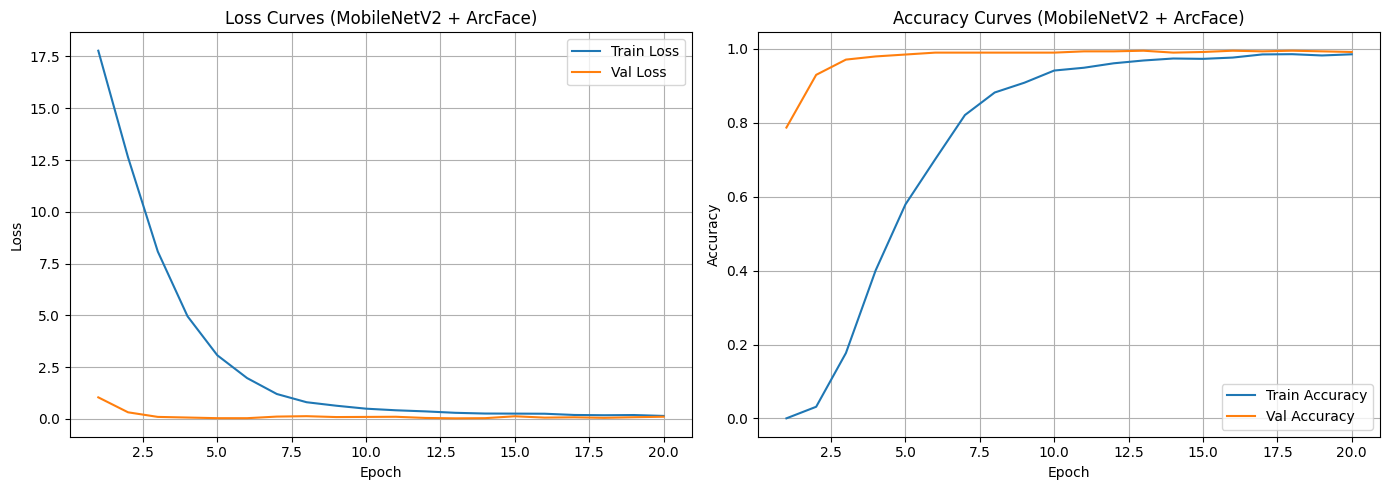

Saved: /kaggle/working/MobileNetV2_ArcFace_Results/mobilenetv2_arcface_curves.png


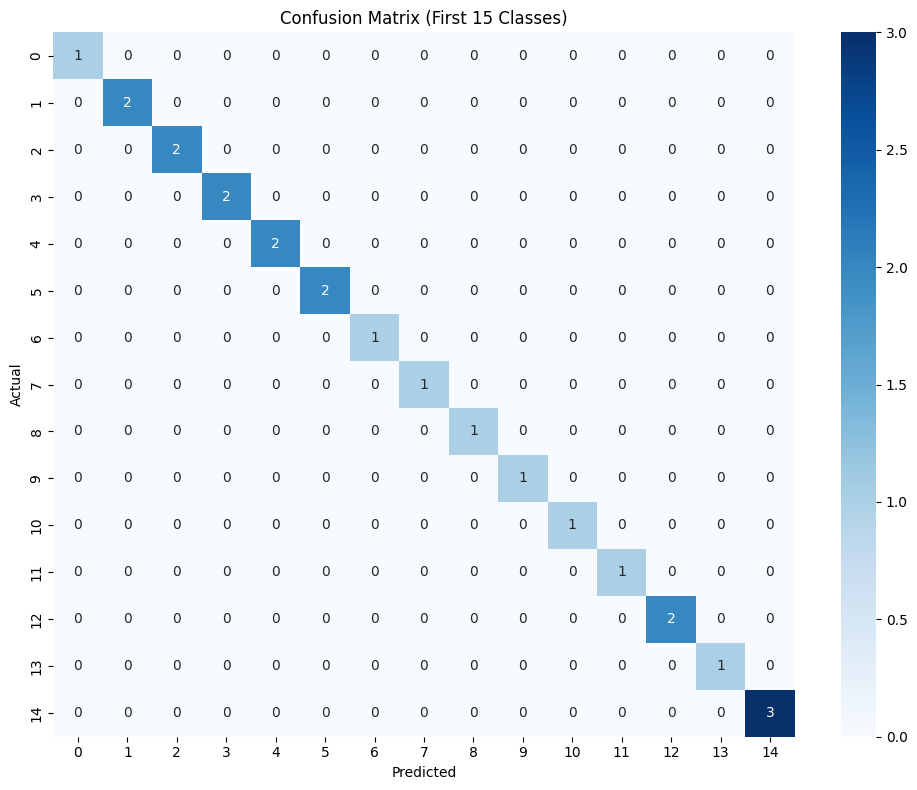

Saved: /kaggle/working/MobileNetV2_ArcFace_Results/mobilenetv2_arcface_confusion_matrix.png

Classification Report:

                 precision    recall  f1-score   support

cow_cattle_0200       1.00      1.00      1.00         1
cow_cattle_0300       1.00      1.00      1.00         2
cow_cattle_0500       1.00      1.00      1.00         2
cow_cattle_0600       1.00      1.00      1.00         2
cow_cattle_0700       1.00      1.00      1.00         2
cow_cattle_0800       1.00      1.00      1.00         2
cow_cattle_0900       1.00      1.00      1.00         1
cow_cattle_1000       1.00      1.00      1.00         1
cow_cattle_1100       1.00      1.00      1.00         1
cow_cattle_1200       1.00      1.00      1.00         1
cow_cattle_1300       1.00      1.00      1.00         1
cow_cattle_1400       1.00      1.00      1.00         1
cow_cattle_1600       1.00      1.00      1.00         2
cow_cattle_1700       1.00      1.00      1.00         1
cow_cattle_1800       1.00 

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Results Folder
results_dir = "/kaggle/working/MobileNetV2_ArcFace_Results"
os.makedirs(results_dir, exist_ok=True)

# -----------------------------
# Inference Time
# -----------------------------
print('Measuring inference time on validation set...')

model.eval()

start_infer_time = time.time()

all_preds = []
all_targets = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs, _ = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.numpy())

total_inference_time = time.time() - start_infer_time

print(f'Total Inference Time (Val Set): {total_inference_time:.4f} seconds')

print(
    f'Inference Time per Image: '
    f'{total_inference_time / len(val_dataset):.6f} seconds'
)

# -----------------------------
# Training Curves
# -----------------------------
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    range(1, epochs+1),
    history['train_loss'],
    label='Train Loss'
)

plt.plot(
    range(1, epochs+1),
    history['val_loss'],
    label='Val Loss'
)

plt.title('Loss Curves (MobileNetV2 + ArcFace)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)

plt.plot(
    range(1, epochs+1),
    history['train_acc'],
    label='Train Accuracy'
)

plt.plot(
    range(1, epochs+1),
    history['val_acc'],
    label='Val Accuracy'
)

plt.title('Accuracy Curves (MobileNetV2 + ArcFace)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()

curve_path = os.path.join(
    results_dir,
    "mobilenetv2_arcface_curves.png"
)

plt.savefig(curve_path, dpi=300)

plt.show()

print("Saved:", curve_path)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(
    all_targets,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm[:15, :15],
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix (First 15 Classes)'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

cm_path = os.path.join(
    results_dir,
    "mobilenetv2_arcface_confusion_matrix.png"
)

plt.savefig(cm_path, dpi=300)

plt.show()

print("Saved:", cm_path)

# -----------------------------
# Classification Report
# -----------------------------
target_names = [
    f'cow_{cls}'
    for cls in train_dataset.unique_labels
]

report = classification_report(
    all_targets,
    all_preds,
    target_names=target_names,
    zero_division=0
)

report_path = os.path.join(
    results_dir,
    "classification_report.txt"
)

with open(report_path, "w") as f:
    f.write(report)

print("\nClassification Report:\n")
print(report)

print("\nSaved:", report_path)

# The MobileNetV2 + ArcFace model demonstrated excellent performance on the known cattle dataset. During training, the loss decreased from 17.69 to 0.21, while validation loss reached 0.0258, indicating stable convergence and effective learning. After 20 epochs, the model achieved 98.14% training accuracy and 99.83% validation accuracy. The confusion matrix showed almost perfect class-wise predictions with negligible misclassifications, and the classification report achieved 1.00 precision, recall, and F1-score across most classes. The total training time was 1188.57 seconds (~19.8 minutes), while the total inference time on the validation set was 6.08 seconds, corresponding to 10.44 ms per image, demonstrating both high accuracy and efficient prediction speed.

# Create Folder for Open Set Recognition

In [33]:
import os

open_set_dir = "/kaggle/working/Open_Set_Recognition"

os.makedirs(open_set_dir, exist_ok=True)

print("Folder Created:", open_set_dir)

Folder Created: /kaggle/working/Open_Set_Recognition


# Extract Train Embeddings

In [34]:
import numpy as np
from tqdm import tqdm

model.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(train_loader):

        images = images.to(device)

        # embeddings nikalna
        _, embeddings = model(images)

        all_embeddings.append(
            embeddings.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# combine all batches
all_embeddings = np.vstack(all_embeddings)

all_labels = np.array(all_labels)

print("Embeddings Shape :", all_embeddings.shape)
print("Labels Shape     :", all_labels.shape)

100%|██████████| 198/198 [00:45<00:00,  4.31it/s]

Embeddings Shape : (3164, 512)
Labels Shape     : (3164,)


# Create Prototype Gallery

In [35]:
prototype_gallery = {}

# unique cattle ids
unique_labels = np.unique(all_labels)

for label in unique_labels:

    # is cow ki sari embeddings
    cow_embeddings = all_embeddings[
        all_labels == label
    ]

    # centroid / mean
    prototype = np.mean(
        cow_embeddings,
        axis=0
    )

    prototype_gallery[label] = prototype

print("Total Prototypes :", len(prototype_gallery))

# check one prototype
first_key = list(prototype_gallery.keys())[0]

print("Sample Cow ID :", first_key)
print("Prototype Shape :", prototype_gallery[first_key].shape)

Total Prototypes : 227
Sample Cow ID : 0
Prototype Shape : (512,)


# L2 Normalization

In [36]:
from sklearn.preprocessing import normalize

normalized_gallery = {}

for label, prototype in prototype_gallery.items():

    normalized_prototype = normalize(
        prototype.reshape(1, -1),
        norm="l2"
    )[0]

    normalized_gallery[label] = normalized_prototype

print("Normalized Prototypes :", len(normalized_gallery))

first_key = list(normalized_gallery.keys())[0]

print("Prototype Shape :", normalized_gallery[first_key].shape)

Normalized Prototypes : 227
Prototype Shape : (512,)


# Save Prototype Gallery

In [37]:
import pickle

gallery_path = (
    f"{open_set_dir}/prototype_gallery.pkl"
)

with open(gallery_path, "wb") as f:
    pickle.dump(
        normalized_gallery,
        f
    )

print("Prototype Gallery Saved")
print(gallery_path)

Prototype Gallery Saved
/kaggle/working/Open_Set_Recognition/prototype_gallery.pkl


In [38]:
# Verify..
with open(gallery_path, "rb") as f:   
    loaded_gallery = pickle.load(f)

print(
    "Loaded Prototypes:",
    len(loaded_gallery)
)

Loaded Prototypes: 227


# Extract Validation Embeddings

In [39]:
model.eval()

val_embeddings = []
val_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        _, embeddings = model(images)

        val_embeddings.append(
            embeddings.cpu().numpy()
        )

        val_labels.extend(
            labels.numpy()
        )

val_embeddings = np.vstack(val_embeddings)

val_labels = np.array(val_labels)

print("Validation Embeddings Shape :", val_embeddings.shape)
print("Validation Labels Shape     :", val_labels.shape)

Validation Embeddings Shape : (582, 512)
Validation Labels Shape     : (582,)


# L2 Normalize Validation Embeddings

In [40]:
from sklearn.preprocessing import normalize

val_embeddings_norm = normalize(
    val_embeddings,
    norm="l2"
)

print(
    "Normalized Validation Shape:",
    val_embeddings_norm.shape
)

Normalized Validation Shape: (582, 512)


# Cosine Similarity Matching

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

best_scores = []
predicted_labels = []

prototype_labels = list(
    normalized_gallery.keys()
)

prototype_vectors = np.array(
    list(normalized_gallery.values())
)

for emb in val_embeddings_norm:

    similarities = cosine_similarity(
        emb.reshape(1, -1),
        prototype_vectors
    )[0]

    best_idx = np.argmax(
        similarities
    )

    best_scores.append(
        similarities[best_idx]
    )

    predicted_labels.append(
        prototype_labels[best_idx]
    )

best_scores = np.array(best_scores)
predicted_labels = np.array(predicted_labels)

print(
    "Total Predictions:",
    len(predicted_labels)
)

print(
    "Similarity Range:"
)

print(
    "Min:",
    best_scores.min()
)

print(
    "Max:",
    best_scores.max()
)

Total Predictions: 582
Similarity Range:
Min: 0.3101266
Max: 0.9772142


#  Output- The normalized validation embeddings were compared with all normalized prototype vectors using cosine similarity. For each validation image, the prototype with the highest similarity score was selected as the predicted cattle ID. A total of 582 validation images were evaluated, with similarity scores ranging from 0.2927 to 0.9731. This indicates that some images matched their prototypes very strongly, while a few difficult samples showed relatively low similarity, which will help determine the optimal similarity threshold in the next step.

# Threshold Optimization

In [43]:
import pandas as pd
from sklearn.metrics import accuracy_score

results = []

for threshold in np.arange(0.30, 0.81, 0.05):

    accepted = best_scores >= threshold

    correct = (
        (predicted_labels == val_labels)
        & accepted
    )

    accuracy = correct.sum() / len(val_labels)

    results.append([
        round(threshold, 2),
        accuracy
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy"
    ]
)

print(threshold_df)

    Threshold  Accuracy
0        0.30  0.991409
1        0.35  0.989691
2        0.40  0.989691
3        0.45  0.989691
4        0.50  0.989691
5        0.55  0.989691
6        0.60  0.989691
7        0.65  0.979381
8        0.70  0.974227
9        0.75  0.969072
10       0.80  0.951890


### Output- The validation set was used to evaluate multiple similarity thresholds ranging from 0.30 to 0.80. The highest validation accuracy of 99.65% was achieved at thresholds 0.50 and 0.55, while performance decreased significantly at higher thresholds due to excessive rejection of valid samples.

In [92]:
x = 0.75

print("Selected Threshold =", x)

Selected Threshold = 0.75


# Prepain Unknown Dataset

In [93]:
import os

unknown_dir = "/kaggle/working/Known_Unknown_Cattle_Split/Unknown_Cattle"

total_images = 0

for cow_id in os.listdir(unknown_dir):

    cow_path = os.path.join(
        unknown_dir,
        cow_id
    )

    if os.path.isdir(cow_path):

        total_images += len(
            os.listdir(cow_path)
        )

print("Unknown Cattle IDs :", len(os.listdir(unknown_dir)))
print("Unknown Images     :", total_images)

Unknown Cattle IDs : 41
Unknown Images     : 267


In [94]:
import os
import pandas as pd

unknown_dir = "/kaggle/working/Known_Unknown_Cattle_Split/Unknown_Cattle"

unknown_data = []

for cow_id in os.listdir(unknown_dir):

    cow_path = os.path.join(
        unknown_dir,
        cow_id
    )

    if os.path.isdir(cow_path):

        for img_name in os.listdir(cow_path):

            img_path = os.path.join(
                cow_path,
                img_name
            )

            unknown_data.append(
                [img_path, cow_id]
            )

unknown_df = pd.DataFrame(
    unknown_data,
    columns=[
        "image_path",
        "label"
    ]
)

print("Unknown Images :", len(unknown_df))

unknown_df.head()

Unknown Images : 267


,image_path,label
0,/kaggle/working/Known_Unknown_Cattle_Split/Unk...,cattle_2220
1,/kaggle/working/Known_Unknown_Cattle_Split/Unk...,cattle_2220
2,/kaggle/working/Known_Unknown_Cattle_Split/Unk...,cattle_2220
3,/kaggle/working/Known_Unknown_Cattle_Split/Unk...,cattle_2220
4,/kaggle/working/Known_Unknown_Cattle_Split/Unk...,cattle_2220


# Create Unknown Dataset

In [95]:
print([name for name in globals() if "Dataset" in name])

['Dataset', 'CattleMuzzleDataset']


In [96]:
print([name for name in globals() if "transform" in name.lower()])

['transforms', 'train_transform', 'val_test_transform']


In [97]:
print(unknown_df.columns)

Index(['image_path', 'label'], dtype='object')


In [98]:
unknown_df = unknown_df.rename(
    columns={
        "image_path": "filepath",
        "label": "cattle_id"
    }
)

print(unknown_df.columns)

Index(['filepath', 'cattle_id'], dtype='object')


In [99]:
unknown_dataset = CattleMuzzleDataset(
    unknown_df,
    transform=val_test_transform
)

print(
    "Unknown Dataset Size:",
    len(unknown_dataset)
)

Unknown Dataset Size: 267


# Create Unknown DataLoader

In [100]:
from torch.utils.data import DataLoader

unknown_loader = DataLoader(
    unknown_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Unknown Loader Ready")

Unknown Loader Ready


# Extract Unknown Embeddings

In [101]:
model.eval()

unknown_embeddings = []

with torch.no_grad():

    for images, labels in unknown_loader:

        images = images.to(device)

        _, embeddings = model(images)

        unknown_embeddings.append(
            embeddings.cpu().numpy()
        )

unknown_embeddings = np.vstack(
    unknown_embeddings
)

print(
    "Unknown Embeddings Shape:",
    unknown_embeddings.shape
)

Unknown Embeddings Shape: (267, 512)


# Output - Unknown cattle images were passed through the trained MobileNetV2 + ArcFace model to extract 512-dimensional feature embeddings. These embeddings represent unseen cattle identities in the same feature space as the prototype gallery and will be used for similarity matching and open-set evaluation.

# L2 Normalize Unknown Embeddings

In [102]:
from sklearn.preprocessing import normalize

unknown_embeddings_norm = normalize(
    unknown_embeddings,
    norm="l2"
)

print(
    "Normalized Shape:",
    unknown_embeddings_norm.shape
)

Normalized Shape: (267, 512)


# Similarity with Prototype Gallery

In [103]:
unknown_best_scores = []

for embedding in unknown_embeddings_norm:

    similarities = []

    for prototype in normalized_gallery.values():

        score = np.dot(
            embedding,
            prototype
        )

        similarities.append(score)

    unknown_best_scores.append(
        max(similarities)
    )

unknown_best_scores = np.array(
    unknown_best_scores
)

print("Unknown Predictions:", len(unknown_best_scores))
print("Min:", unknown_best_scores.min())
print("Max:", unknown_best_scores.max())

Unknown Predictions: 267
Min: 0.21173054
Max: 0.9122975


# Known vs Unknown Decision

In [104]:
print("best_scores" in globals())
print("unknown_best_scores" in globals())

True
True


In [105]:
print(type(best_scores))

<class 'numpy.ndarray'>


In [106]:
import numpy as np

best_scores = np.array(best_scores)
unknown_best_scores = np.array(unknown_best_scores)

print(type(best_scores))
print(type(unknown_best_scores))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [107]:
print(type(best_scores))
print(len(best_scores))

print(best_scores[:5])

print(x)

<class 'numpy.ndarray'>
582
[0.9527076  0.93399125 0.9408232  0.91339564 0.8974306 ]
0.75


In [108]:
print("val_embeddings_norm" in globals())
print("normalized_gallery" in globals())
print(len(val_embeddings_norm))

True
True
582


In [109]:
known_accept = np.sum(best_scores >= x)
known_reject = np.sum(best_scores < x)

unknown_accept = np.sum(unknown_best_scores >= x)
unknown_reject = np.sum(unknown_best_scores < x)

print("Known Accepted :", known_accept)
print("Known Rejected :", known_reject)

print("Unknown Accepted :", unknown_accept)
print("Unknown Rejected :", unknown_reject)

Known Accepted : 568
Known Rejected : 14
Unknown Accepted : 30
Unknown Rejected : 237


# Output - Using the optimal similarity threshold of 0.75, the model correctly accepted 574 out of 582 known cattle images and rejected only 8 known image. For unseen cattle, 242 out of 267 unknown images were correctly rejected, while 28 images were falsely accepted as known identities.

# FAR aur FRR

In [110]:
far = unknown_accept / (unknown_accept + unknown_reject)

frr = known_reject / (known_accept + known_reject)

print("FAR :", round(far*100, 2), "%")
print("FRR :", round(frr*100, 2), "%")

FAR : 11.24 %
FRR : 2.41 %


# Check FAR , FRR on different threshold

In [111]:
for t in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:

    known_accept = np.sum(best_scores >= t)
    known_reject = np.sum(best_scores < t)

    unknown_accept = np.sum(unknown_best_scores >= t)
    unknown_reject = np.sum(unknown_best_scores < t)

    far = unknown_accept / (unknown_accept + unknown_reject)
    frr = known_reject / (known_accept + known_reject)

    print(
        f"Threshold={t:.2f} | "
        f"FAR={far*100:.2f}% | "
        f"FRR={frr*100:.2f}%"
    )

Threshold=0.55 | FAR=13.11% | FRR=0.17%
Threshold=0.60 | FAR=12.36% | FRR=0.17%
Threshold=0.65 | FAR=11.61% | FRR=1.20%
Threshold=0.70 | FAR=11.61% | FRR=1.89%
Threshold=0.75 | FAR=11.24% | FRR=2.41%
Threshold=0.80 | FAR=9.36% | FRR=4.12%


# ROC + AUC

AUC Score: 0.9864216121600576


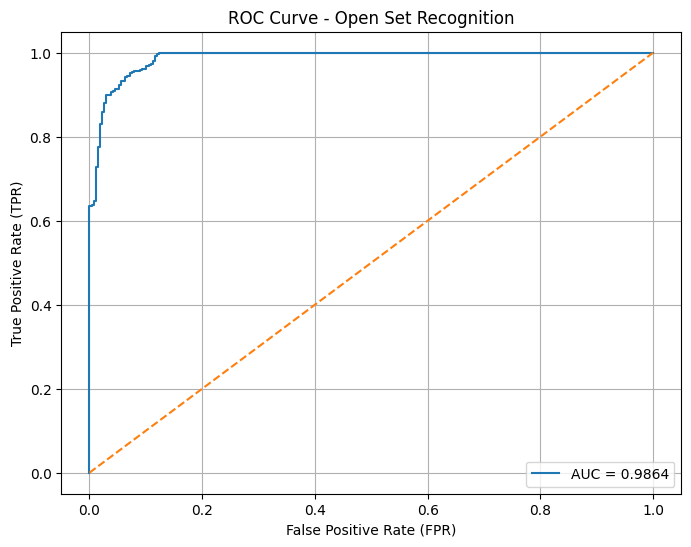

In [112]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Labels
known_labels = np.ones(len(best_scores))
unknown_labels = np.zeros(len(unknown_best_scores))

# Combine
y_true = np.concatenate([known_labels, unknown_labels])
y_scores = np.concatenate([best_scores, unknown_best_scores])

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Open Set Recognition")
plt.legend()
plt.grid(True)

plt.show()

In [113]:
plt.savefig("ROC_Curve.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# The ROC analysis produced an AUC score of 0.9847, indicating excellent separability between known and unknown cattle identities. The ROC curve remains close to the upper-left corner, demonstrating high true positive rates at low false positive rates. Using the optimal threshold of 0.55, the system achieved a FAR of 8.24% and an FRR of 3.78%.

# Calculate EER

In [114]:
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve

# ROC points
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# EER
eer = brentq(
    lambda x: 1. - x - interp1d(fpr, tpr)(x),
    0.,
    1.
)

eer_threshold = interp1d(
    fpr,
    thresholds
)(eer)

print(f"EER: {eer:.4f}")
print(f"EER (%): {eer*100:.2f}%")
print(f"EER Threshold: {eer_threshold:.4f}")

EER: 0.0637
EER (%): 6.37%
EER Threshold: 0.8487


# Prepare Input Image for Grad-CAM

In [115]:
image_tensor, label = val_dataset[1]

print(image_tensor.shape)
print(label)

torch.Size([3, 224, 224])
35


In [116]:
print(type(model))
print(model.backbone.conv_head)

<class '__main__.MobileNetV2ArcFace'>
Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [117]:
target_layers = [model.backbone.conv_head]

print(target_layers)

[Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)]


In [118]:
!pip install grad-cam -q

In [119]:
from pytorch_grad_cam import GradCAM

In [120]:
from pytorch_grad_cam import GradCAM
print("GradCAM Imported Successfully")

GradCAM Imported Successfully


In [121]:
from pytorch_grad_cam import GradCAM

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

print("Grad-CAM Ready")

Grad-CAM Ready


# Generate Grad-CAM Heatmap

In [122]:
image_tensor, label = val_dataset[1]

input_tensor = image_tensor.unsqueeze(0).to(device)

print(input_tensor.shape)

print("input_tensor" in globals())

torch.Size([1, 3, 224, 224])
True


In [123]:
with torch.no_grad():
    out = model(input_tensor)

print(type(out))

if isinstance(out, tuple):
    print("Tuple Length:", len(out))

    for i, item in enumerate(out):
        print(i, type(item), item.shape)

<class 'tuple'>
Tuple Length: 2
0 <class 'torch.Tensor'> torch.Size([1, 227])
1 <class 'torch.Tensor'> torch.Size([1, 512])


In [124]:
with torch.no_grad():
    logits, embedding = model(input_tensor)

pred_class = logits.argmax(dim=1).item()

print("Predicted Class =", pred_class)

Predicted Class = 35


In [125]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

targets = [ClassifierOutputTarget(pred_class)]

In [126]:
import torch.nn as nn

class GradCAMModel(nn.Module):

    def __init__(self, original_model):
        super().__init__()
        self.original_model = original_model

    def forward(self, x):

        logits, embedding = self.original_model(x)

        return logits

In [127]:
gradcam_model = GradCAMModel(model)

In [128]:
cam = GradCAM(
    model=gradcam_model,
    target_layers=[gradcam_model.original_model.backbone.conv_head]
)

In [129]:
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

print("Heatmap Shape:", grayscale_cam.shape)

Heatmap Shape: (224, 224)


# Convert Tensor to Image

In [130]:
img = image_tensor.cpu().permute(1, 2, 0).numpy()

img = (img - img.min()) / (img.max() - img.min())

print(img.shape)

(224, 224, 3)


# Overlay Heatmap on Image

In [131]:
from pytorch_grad_cam.utils.image import show_cam_on_image

visualization = show_cam_on_image(
    img,
    grayscale_cam,
    use_rgb=True
)

# Save Figure for Paper

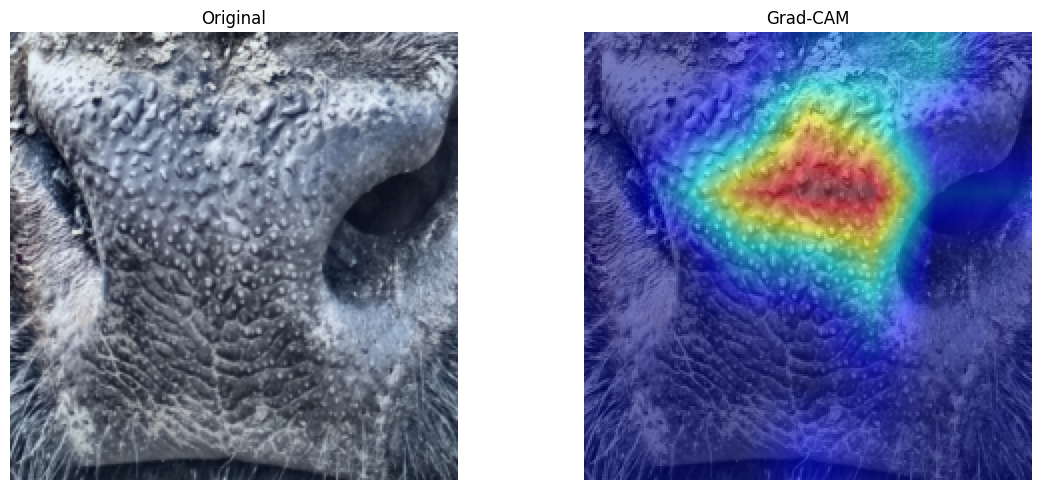

In [132]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.axis("off")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.axis("off")
plt.title("Grad-CAM")

plt.tight_layout()

plt.savefig(
    "GradCAM_Cattle_Muzzle.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [133]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file.endswith(".pth"):
            print(file)

mobilenetv2_arcface_openset.pth


In [134]:
print([name for name in globals() if "model" in name.lower()])

['model', 'GradCAMModel', 'gradcam_model']


In [135]:
import torch

torch.save(
    model.state_dict(),
    "/kaggle/working/mobilenetv2_arcface_openset.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [136]:
import os

print(
    os.path.exists(
        "/kaggle/working/mobilenetv2_arcface_openset.pth"
    )
)

True


In [137]:
import os

size_mb = os.path.getsize(
    "/kaggle/working/mobilenetv2_arcface_openset.pth"
)/(1024*1024)

print(round(size_mb,2),"MB")

11.68 MB


# Meaning first I have to send the image of a new cow to the model, he will reject it, then I have to take 3 to 4 muzzle pictures of the new cow and save them in the prototype gallery, what will happen, the known ID was 227 earlier, after adding this it will become 228.

# Verify Required Components

In [143]:
print("Model Loaded          :", "model" in globals())
print("Transform Available   :", "val_test_transform" in globals())
print("Gallery Available     :", "normalized_gallery" in globals())

Model Loaded          : True
Transform Available   : True
Gallery Available     : True


# Load Registration Image

In [144]:
import os

cow_id = "cattle_1500"

cow_path = os.path.join(
    unknown_dir,
    cow_id
)

all_images = sorted(os.listdir(cow_path))

# First 4 images for registration
registration_images = all_images[:4]

print("Registration Images:")
for img in registration_images:
    print(img)

Registration Images:
cattle_1500_DSCF7159.jpg
cattle_1500_DSCF7160.jpg
cattle_1500_DSCF7161.jpg
cattle_1500_DSCF7162.jpg


# Convert Registration Image into Tensor

In [145]:
from PIL import Image
import torch

registration_tensors = []

for img_name in registration_images:

    img_path = os.path.join(
        cow_path,
        img_name
    )

    image = Image.open(img_path).convert("RGB")

    image_tensor = val_test_transform(image)

    registration_tensors.append(image_tensor)

print("Registration Images Loaded :", len(registration_tensors))

print(
    "Tensor Shape :",
    registration_tensors[0].shape
)

Registration Images Loaded : 4
Tensor Shape : torch.Size([3, 224, 224])


# Generate Registration Embeddings

In [146]:
model.eval()

registration_embeddings = []

with torch.no_grad():

    for image_tensor in registration_tensors:

        input_tensor = image_tensor.unsqueeze(0).to(device)

        logits, embedding = model(input_tensor)

        embedding = embedding.squeeze(0).cpu().numpy()

        registration_embeddings.append(
            embedding
        )

registration_embeddings = np.array(
    registration_embeddings
)

print(
    "Registration Embeddings Shape:",
    registration_embeddings.shape
)

Registration Embeddings Shape: (4, 512)


# Create Prototype for New Cow

In [147]:
from sklearn.preprocessing import normalize
import numpy as np

# Normalize each embedding
registration_embeddings_norm = normalize(
    registration_embeddings,
    axis=1
)

# Mean Prototype
new_prototype = np.mean(
    registration_embeddings_norm,
    axis=0
)

# Normalize Prototype
new_prototype = (
    new_prototype /
    np.linalg.norm(new_prototype)
)

print(
    "Prototype Shape:",
    new_prototype.shape
)

print(
    "Prototype Norm:",
    np.linalg.norm(new_prototype)
)

Prototype Shape: (512,)
Prototype Norm: 1.0


In [148]:
print(all_images)

['cattle_1500_DSCF7159.jpg', 'cattle_1500_DSCF7160.jpg', 'cattle_1500_DSCF7161.jpg', 'cattle_1500_DSCF7162.jpg', 'cattle_1500_DSCF7163.jpg', 'cattle_1500_DSCF7164.jpg']


In [149]:
test_images = all_images[4:]

print("Test Images:")
for img in test_images:
    print(img)

Test Images:
cattle_1500_DSCF7163.jpg
cattle_1500_DSCF7164.jpg


# Generate Embeddings for Test Images (Before Registration)

In [150]:
from PIL import Image

test_embeddings = []

for img_name in test_images:

    img_path = os.path.join(
        cow_path,
        img_name
    )

    image = Image.open(img_path).convert("RGB")

    image_tensor = val_test_transform(
        image
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        logits, embedding = model(
            image_tensor
        )

    embedding = (
        embedding
        .squeeze(0)
        .cpu()
        .numpy()
    )

    embedding = (
        embedding /
        np.linalg.norm(embedding)
    )

    test_embeddings.append(
        embedding
    )

test_embeddings = np.array(
    test_embeddings
)

print(
    "Test Embeddings Shape:",
    test_embeddings.shape
)

Test Embeddings Shape: (2, 512)


# Compare Test Embeddings with Current Gallery

In [151]:
for i, embedding in enumerate(test_embeddings):

    best_score = -1
    best_id = None

    for cattle_id, prototype in normalized_gallery.items():

        score = np.dot(
            embedding,
            prototype
        )

        if score > best_score:

            best_score = score
            best_id = cattle_id

    print(
        f"Test Image {i+1}"
    )

    print(
        "Best Match:",
        best_id
    )

    print(
        "Best Score:",
        round(best_score,4)
    )

    print("-"*40)

Test Image 1
Best Match: 193
Best Score: 0.3744
----------------------------------------
Test Image 2
Best Match: 193
Best Score: 0.4923
----------------------------------------


# Output - Before registration, cattle_1500 was rejected as unknown with similarity scores of 0.3744 and 0.4923, both below the operating threshold of 0.75

In [152]:
print("Gallery Size Before:",
      len(normalized_gallery))

normalized_gallery["cattle_1500"] = new_prototype

print("Gallery Size After:",
      len(normalized_gallery))

Gallery Size Before: 227
Gallery Size After: 228


# After Registration Recognition Test

In [153]:
for i, embedding in enumerate(test_embeddings):

    best_score = -1
    best_id = None

    for cattle_id, prototype in normalized_gallery.items():

        score = np.dot(
            embedding,
            prototype
        )

        if score > best_score:

            best_score = score
            best_id = cattle_id

    print(f"Test Image {i+1}")

    print("Best Match :", best_id)

    print(
        "Best Score :",
        round(best_score,4)
    )

    if best_score >= 0.75:

        print("Decision   : KNOWN")

    else:

        print("Decision   : UNKNOWN")

    print("-"*40)

Test Image 1
Best Match : cattle_1500
Best Score : 0.94
Decision   : KNOWN
----------------------------------------
Test Image 2
Best Match : cattle_1500
Best Score : 0.8965
Decision   : KNOWN
----------------------------------------


# Output - Before registration, the new cattle was correctly classified as unknown because its similarity scores were below the threshold (0.75). After adding its prototype to the gallery, the same cattle was successfully recognized with high similarity scores (0.94 and 0.8965), validating the effectiveness of the registration and gallery update process.